# INFO-6151-(01)-26W Data Visualization for Machine Learning
## Capstone Project: Global Risk Dynamics: Quantifying Geopolitical Shocks & Trade Policy Impacts
**Date:** March 28th, 2026

**Group Members:**
* Yun-Jiung Wang (1256222)
* Andrew Polk (1161715)
* Kaosicho Ebenebe (1242551)​

---

### 1. Project Objective
This project analyzes and visualizes the resilience of different US industrial sectors under the dual pressure of Global Tariff Policies and the 2026 Iranian Conflict. We utilize the `yfinance` library to extract financial data and evaluate how specific Exchange Traded Funds (ETFs) and market sentiment indicators respond to these macroeconomic and geopolitical shocks.

### 2. Research Scope
We focus on five key assets and one sentiment benchmark to represent diverse segments of the global economy:

* **SPY:** S&P 500 (Broad Market Benchmark)
* **QQQ:** Nasdaq 100 (Technology & Innovation)
* **ITA:** Aerospace & Defense (National Security)
* **ICLN:** Clean Energy (Future Sustainability)
* **VDE:** Vanguard Energy (Traditional Oil & Gas)
* **VIX:** CBOE Volatility Index (Market Sentiment & "Fear Gauge")

### 3. Methodology & Technical Implementation
* **Data Acquisition:** Extracted historical adjusted closing prices using Python and `yfinance`.
* **Event Study Analysis:** Mapped specific dates of tariff announcements (Policy Risk) and military escalations (Conflict Risk) against market performance.
* **Predictive Modeling:** Implemented an XGBoost Regression model to predict market volatility (VIX) trends using lagged sector returns.

### 4. Project Motivation
* **Geopolitical Sensitivity:** Global markets are increasingly sensitive to non-economic shocks, specifically the divergence between policy risks (Tariffs) and conflict risks (Iran).

* **Strategic Asset Misallocation:** Traditional hedging often fails during rapid sector decoupling; identifying safe havens like ITA vs. QQQ is critical for capital preservation.


### 5. Expected Deliverables
* **Interactive Dashboard:** A Plotly Dash interface highlighting performance changes and VIX spikes during key events.
* **Risk Assessment Metrics:** Calculation of maximum drawdowns and correlation matrices to measure hedging effectiveness.
* **XGBoost Feature Importance:** Visual analysis identifying which sector contributes most to the accuracy of the volatility prediction model.

## Install Dependencies for Colab

In [ ]:
try:
    import yfinance
except ImportError:
    !pip install yfinance

try:
    import dash
except ImportError:
    !pip install dash comm

try:
    import streamlit
except ImportError:
    print("Installing streamlit...")
    !pip install streamlit -q

try:
    import pyngrok
except ImportError:
    print("Installing pyngrok...")
    !pip install pyngrok -q

# 4. SHAP
try:
    import shap
except ImportError:
    print("Installing shap...")
    !pip install shap -q

# 5. Localtunnel (Colab preview Streamlit)
import os
if os.system("command -v lt > /dev/null") != 0:
    print("Installing localtunnel...")
    !npm install -g localtunnel -q

print("All dependencies are ready.")

All dependencies are ready.


## **Import Libs**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
import requests
import plotly.express as px
import seaborn as sns

from datetime import datetime
from dateutil.relativedelta import relativedelta
from plotly.subplots import make_subplots
from dash import Dash, dcc, html, Input, Output
from google.colab import output

import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import plotly.express as px
import scipy.stats as stats

import shap

## **Phase 1: Data Preparation and Feature Engineering**


Instead of using raw price levels, we utilize Daily Percentage Returns as our primary features. This ensures data stationarity, which is a requirement for most machine learning algorithms. By calculating the relative change against the previous day's closing price, the model focuses on market volatility and momentum rather than long-term price trends. The inclusion of lagged features (T-1 to T-5) allows the XGBoost model to detect short-term behavioral patterns triggered by geopolitical events.


### **1. Data Collection:**

1.1. Define required tickers

1.2. Download the raw data

1.3. Display first 2 rows

In [ ]:
# Define the Stocks for observation
STOCKS = {
    "SPY": "Market",
    "QQQ": "Tech",
    "ITA": "Defense",
    "ICLN": "Clean Energy",
    "VDE": "Energy"
}

# Define date region
today = datetime.today()
START= (today - relativedelta(years=2)).strftime("%Y-%m-%d")
END = datetime.today().strftime("%Y-%m-%d")

tickers = list(STOCKS.keys()) + ["^VIX"]
print(f"\nLoad data from {START} to {END}")
# Download the dataset
df_raw = yf.download(tickers, start=START, end=END, auto_adjust=True)

df_raw.head(2)


Load data from 2024-04-01 to 2026-04-01


[*********************100%***********************]  6 of 6 completed


Price           Close                                                         \
Ticker           ICLN         ITA         QQQ         SPY         VDE   ^VIX   
Date                                                                           
2024-04-01  13.495602  129.119019  440.116455  509.754059  124.683952  13.65   
2024-04-02  13.273411  128.467926  436.318176  506.513062  126.339272  14.61   

Price            High                                      ...        Open  \
Ticker           ICLN         ITA         QQQ         SPY  ...         QQQ   
Date                                                       ...               
2024-04-01  13.621187  130.411291  442.668415  511.921345  ...  440.136227   
2024-04-02  13.437638  128.931568  436.634707  506.649690  ...  435.299366   

Price                                       Volume                    \
Ticker             SPY         VDE   ^VIX     ICLN     ITA       QQQ   
Date                                                                   
2024-04-01  511.384424  124.204281  13.61  3284300  238200  38729000   
2024-04-02  505.927281  125.285900  13.74  5033400  685800  44259700   

Price                              
Ticker           SPY     VDE ^VIX  
Date                               
2024-04-01  62477500  658000    0  
2024-04-02  74230300  528700    0  

[2 rows x 30 columns]

### **1.2. Data Preprocessing:**





#### **1.2.1. Flattening MultiIndex Data:**


  The initial dataset retrieved from yfinance contains a MultiIndex structure, which is complex for direct visualization. To simplify our workflow, we extracted only the adjusted closing prices and flattened the column headers. This process ensures the DataFrame is compatible with Plotly and easier for team members to perform further calculations, such as daily returns or volatility analysis.


In [ ]:
# Get the Adj close data
df_final = df_raw['Close'].copy()

# Remove label name 'Ticker'
df_final.columns.name = None

# Convert Date to normal columns
df_final = df_final.reset_index()

# Rename ^VIX to VIX
df_final = df_final.rename(columns={'^VIX': 'VIX'})

# Verification:
print("Transformed DataFrame (Single Level Column):")
print(df_final.head())
print("\nColumns list:", df_final.columns.tolist())

Transformed DataFrame (Single Level Column):
        Date       ICLN         ITA         QQQ         SPY         VDE  \
0 2024-04-01  13.495602  129.119019  440.116455  509.754059  124.683952   
1 2024-04-02  13.273411  128.467926  436.318176  506.513062  126.339272   
2 2024-04-03  13.360355  127.905670  437.297424  507.069427  127.345596   
3 2024-04-04  13.350694  128.408722  430.610840  500.880127  127.185707   
4 2024-04-05  13.205790  129.572769  435.685120  506.112671  128.568283   

         VIX  
0  13.650000  
1  14.610000  
2  14.330000  
3  16.350000  
4  16.030001  

Columns list: ['Date', 'ICLN', 'ITA', 'QQQ', 'SPY', 'VDE', 'VIX']


#### **1.2.1.1 Data quality diagnostics (missing values ​​and outliers)**

* **Missing Data Heatamp**

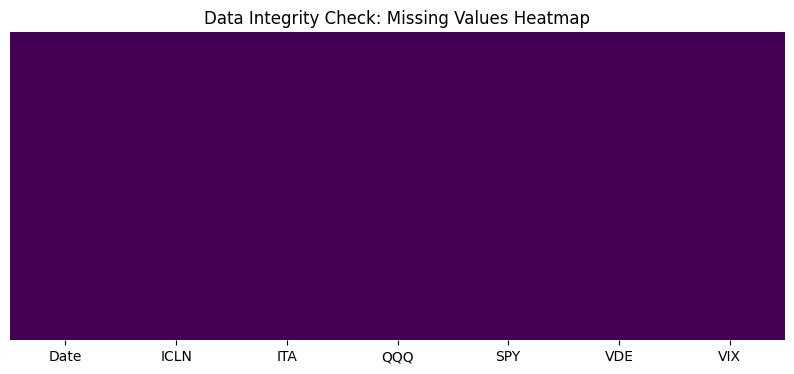

In [ ]:
# Missing Data Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df_final.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Data Integrity Check: Missing Values Heatmap")
plt.show()

#### **Observation of Missing Data:**
By the heatmap diagnostics, our data showed 100% integrity, with no systematic or random missing patterns detected. Therefore, this project did not require data imputation, ensuring the purity of the original financial signals.




#### **1.2.2 Data Normalization (Base 100):**

For visualization, we need to normalize the data to make them comparable.

In [ ]:
df_norm = df_final.copy()

# remove the date column for normalization
cols_to_norm = [col for col in df_norm.columns if col != 'Date']

for col in cols_to_norm:
    # make the first day's value 100
    df_norm[col] = (df_norm[col] / df_norm[col].iloc[0]) * 100

print("Normalization Complete. All assets now start at 100.")

Normalization Complete. All assets now start at 100.


####  **Performance Indexing (Base-100)**

To provide an actionable comparison for executive decision-making, we converted all raw asset prices into a Performance Index (Base-100). This methodology eliminates the 'price-scale bias' inherent in raw stock prices, allowing for a synchronized evaluation of how disparate sectors—ranging from high-growth Technology (QQQ) to defensive Aerospace & Defense (ITA)—responded to the same systemic shocks. By anchoring all assets to a common starting point, the visualization clearly delineates sector-specific resilience and identifies strategic hedging opportunities during periods of geopolitical instability.

In [ ]:
# === Step 1:remove VIX ===
# 5 ETFs in different fields
tickers_to_plot = ['SPY', 'QQQ', 'ITA', 'ICLN', 'VDE']
df_plot_all = df_norm[['Date'] + tickers_to_plot].melt(id_vars='Date', var_name='Asset', value_name='Normalized_Value')

# === Step 2:single graph ===
fig_all = px.line(df_plot_all,
                  x='Date',
                  y='Normalized_Value',
                  color='Asset',
                  title="Cumulative Performance Analysis: Impact of Global Shocks (Base 100)",
                  labels={'Normalized_Value': 'Performance (Start = 100)'},
                  color_discrete_map={
                      "SPY": "gray",      # gray for baseline
                      "ITA": "red",       # defense
                      "VDE": "darkorange",# energy
                      "QQQ": "blue",      # tech
                      "ICLN": "green"     # clean energy
                  })

# === Step 3: add event ===
events = [
    {"date": "2025-04-02", "label": "2025 Tariff", "color": "black"},
    {"date": "2026-02-28", "label": "2026 Israel strikes Iran", "color": "darkred"}
]

for event in events:
    fig_all.add_vline(x=event["date"],
                      line_dash="dash",
                      line_color=event["color"],
                      line_width=2)

    fig_all.add_annotation(x=event["date"],
                           y=1.05,
                           yref="paper",
                           text=event["label"],
                           showarrow=False,
                           textangle=-45,
                           font=dict(color=event["color"], size=10))

# === Step 4: ===
fig_all.update_layout(
    template="plotly_white",
    hovermode="x unified",
    xaxis_title="Timeline (2024 - 2026)",
    yaxis_title="Asset Value (Base 100)",
    legend_title="Sectors",
    height=600
)

fig_all.show()

#### **1.2.3. Calculate Returns**

Convert prices to percentage change for machine learning compatibility

In [ ]:
# Set Date as index for time series operations
df_ml = df_final.set_index('Date').copy()
df_returns = df_ml.pct_change().dropna()

display(df_returns.head(2))
display(df_ml.head(2))

,ICLN,ITA,QQQ,SPY,VDE,VIX
Date,,,,,,
2024-04-02,-0.016464,-0.005043,-0.008630,-0.006358,0.013276,0.070330
2024-04-03,0.006550,-0.004377,0.002244,0.001098,0.007965,-0.019165


,ICLN,ITA,QQQ,SPY,VDE,VIX
Date,,,,,,
2024-04-01,13.495602,129.119019,440.116455,509.754059,124.683952,13.65
2024-04-02,13.273411,128.467926,436.318176,506.513062,126.339272,14.61


#### **Outlier Observation:**

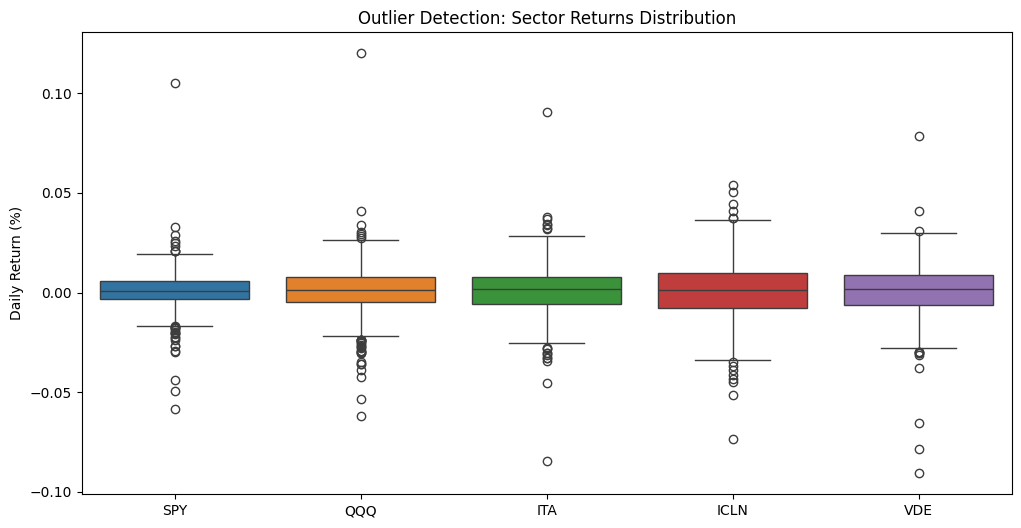

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_returns[list(STOCKS.keys())])

plt.title("Outlier Detection: Sector Returns Distribution")

plt.ylabel("Daily Return (%)")

plt.show()

#### **1.2.4. Create Lagged Features:**

Generate features representing the past 5 days of market activity


In [ ]:
lags = 5
df_features = df_returns.copy()

for col in df_returns.columns:
    for i in range(1, lags + 1):
        df_features[f'{col}_lag_{i}'] = df_returns[col].shift(i)

# Remove rows with missing values caused by the shifting operation
df_ml_ready = df_features.dropna()

#### **1.2.5. Indexing Before and After:**

The chart below traces SPY through each transformation step so the audience can see exactly what the data looks like before and after preprocessing:
| Step | What changes | Why it matters |
|------|-------------|----------------|
| Raw close price | Absolute dollar level | Non-stationary; model can't generalize across price scales |
| Daily % return (Step 2.3) | Day-over-day % change | Stationary signal; removes price-scale bias |
| Lagged return (Step 2.4) | Yesterday's return as today's feature | Gives the model temporal context without look-ahead |

In [ ]:
SAMPLE_TICKER = "SPY"

raw_prices = df_final.set_index("Date")[SAMPLE_TICKER] # BEFORE: raw close
pct_return = df_returns[SAMPLE_TICKER] # AFTER step 2.3: % return
lag1 = df_ml_ready[f"{SAMPLE_TICKER}_lag_1"] # AFTER step 2.4: lag-1 return

fig_ba = make_subplots(
    rows=3, cols=1,
    subplot_titles=[
        f"BEFORE  – {SAMPLE_TICKER} Raw Close Price",
        f"AFTER (Step 2.3) – {SAMPLE_TICKER} Daily % Return",
        f"AFTER (Step 2.4) – {SAMPLE_TICKER} 1-Day Lagged Return",
    ],
    shared_xaxes=True,
    vertical_spacing=0.10,
)

fig_ba.add_trace(
    go.Scatter(x=raw_prices.index, y=raw_prices.values,
               mode="lines", line=dict(color="royalblue"), name="Raw Price"),
    row=1, col=1,
)
fig_ba.add_trace(
    go.Scatter(x=pct_return.index, y=pct_return.values * 100,
               mode="lines", line=dict(color="darkorange"), name="% Return"),
    row=2, col=1,
)
fig_ba.add_trace(
    go.Scatter(x=lag1.index, y=lag1.values * 100,
               mode="lines", line=dict(color="seagreen"), name="Lag-1 Return"),
    row=3, col=1,
)

fig_ba.update_yaxes(title_text="Price (USD)", row=1, col=1)
fig_ba.update_yaxes(title_text="Return (%)",  row=2, col=1)
fig_ba.update_yaxes(title_text="Return (%)",  row=3, col=1)
fig_ba.update_xaxes(title_text="Date",        row=3, col=1)

fig_ba.update_layout(
    title_text="Preprocessing: Before & After Transformation (SPY)",
    template="plotly_white",
    height=750,
    showlegend=False,
)
fig_ba.show()

print(f"BEFORE – df_final shape    : {df_final.shape}")
print(f"AFTER  – df_ml_ready shape : {df_ml_ready.shape}")
print(f"Columns added by lagging   : {df_ml_ready.shape[1] - df_returns.shape[1]}")

BEFORE – df_final shape    : (502, 7)
AFTER  – df_ml_ready shape : (496, 36)
Columns added by lagging   : 30


**Event Date Registry:**

Store key observation dates in a dictionary for later usage.



In [ ]:
EVENTS = {
    # Iran War Dates:
    "Israel strikes Iran": "2026-02-28",
    # Trump Tariff Dates:
    "Tariff":"2025-04-02"
}

#### **1.2.6. Define Features (X) and Target (y)**

In [ ]:
# Target variable: VIX
y = df_ml.loc[df_ml_ready.index, 'VIX']

# Feature variables: All sector returns and their lagged values (excluding current day VIX)
X = df_ml_ready.drop(columns=['VIX'])

print(f"Feature Engineering Complete. Matrix shape: {X.shape}")

Feature Engineering Complete. Matrix shape: (496, 35)


## **Phase 2: XGBoost Model Training and Feature Importance Analysis**
We split the data chronologically to train the XGBoost Regressor. Following the training, we visualize the feature importance to determine which sectors are the strongest predictors of market volatility.

### **2.1. Split train/test data**

In [ ]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

#### **2.1.1. Standardization for Multi-Scale Features:**

In this project, we utilize **Standardization** (Z-score scaling) as a critical preprocessing step. While our input features ($X$) consist of **lagged return values** from various secto, our target variable ($y$) is the **absolute VIX level**.

Standardizing the features is essential for the following reasons:
1. **Handling Different Scales**: By transforming return values to have a **mean of 0 and a standard deviation of 1**, we ensure that the XGBoost model treats each sector's contribution fairly, preventing features with slightly larger variances from dominating the model.
2. **Optimizing Model Convergence**: Although tree-based models like XGBoost are relatively robust, standardized data often leads to more stable and faster convergence during the boosting process.
3. **Improving Interpretability (SHAP)**: To satisfy the project's requirement for model explainability, standardization ensures that **SHAP values** are calculated on a consistent scale, allowing us to accurately quantify how specific market shocks push the VIX prediction up or down.



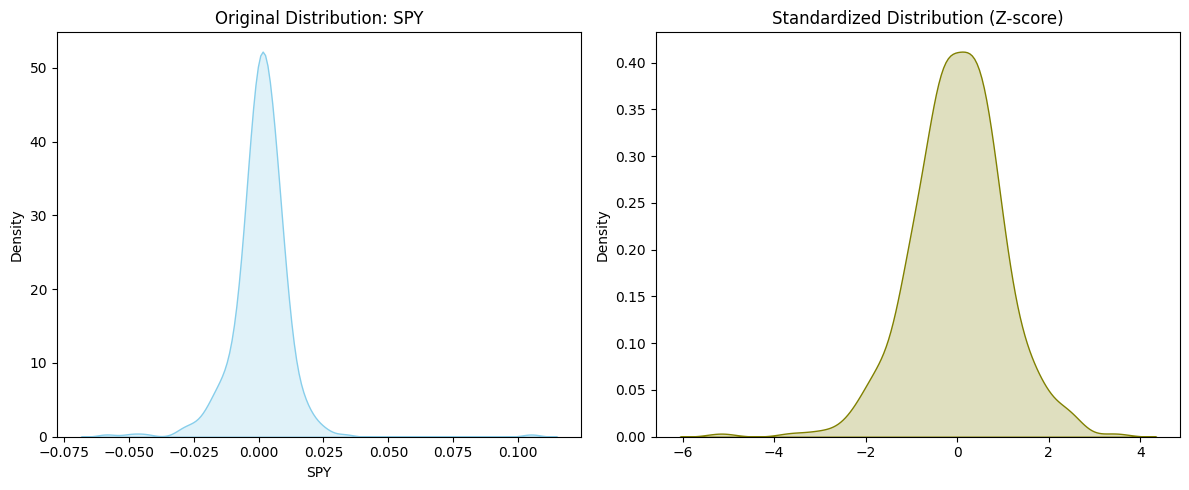

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit on training data and transform both sets
# We fit only on X_train to avoid "Data Leakage"
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. [Visualization Requirement] Compare distribution before and after scaling
# Picking the first feature for demonstration
feature_to_plot = X_train.columns[3]

plt.figure(figsize=(12, 5))

# Plot Before Scaling
plt.subplot(1, 2, 1)
sns.kdeplot(X_train[feature_to_plot], fill=True, color="skyblue")
plt.title(f"Original Distribution: {feature_to_plot}")

# Plot After Scaling
plt.subplot(1, 2, 2)
sns.kdeplot(X_train_scaled[:, 0], fill=True, color="olive")
plt.title(f"Standardized Distribution (Z-score)")

plt.tight_layout()
plt.show()

#### **Visualization Analysis: Impact of StandardScaler**
As shown in the comparison above, the **Standardization** process transforms our sector returns from their raw magnitudes (typically near zero) into a consistent **Z-score scale**.

- **Left Plot**: Represents the original return values, which are difficult to compare across different assets due to varying volatility levels.
- **Right Plot**: Shows the data centered at zero with a unit standard deviation. This visualization confirms that our preprocessing successfully aligns all features, ensuring that the **XGBoost model** and **SHAP interpretability tools** can evaluate each feature's contribution fairly and efficiently.

### **2.2. Initialize and Train XGBoost Regressor**

In [ ]:
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    objective='reg:squarederror',
    random_state=42
)

model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

### **2.3. Evaluate Performance**

To assess the effectiveness of our XGBoost model, we evaluate the predictions using **Root Mean Squared Error (RMSE)** and **R-squared (R²)**. Since our target variable (VIX) is measured in absolute points, the RMSE provides a direct measure of our model's average deviation from the actual market sentiment.

In [ ]:
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Training Complete.")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} (Average prediction error in VIX units)")
print(f"R² Score: {r2:.4f} (Percentage of variance explained)")

Model Training Complete.
Root Mean Squared Error (RMSE): 3.6879 (Average prediction error in VIX units)
R² Score: 0.2422 (Percentage of variance explained)


### **2.4. Model reliability diagnostics (residual plot and Q-Q plot)**

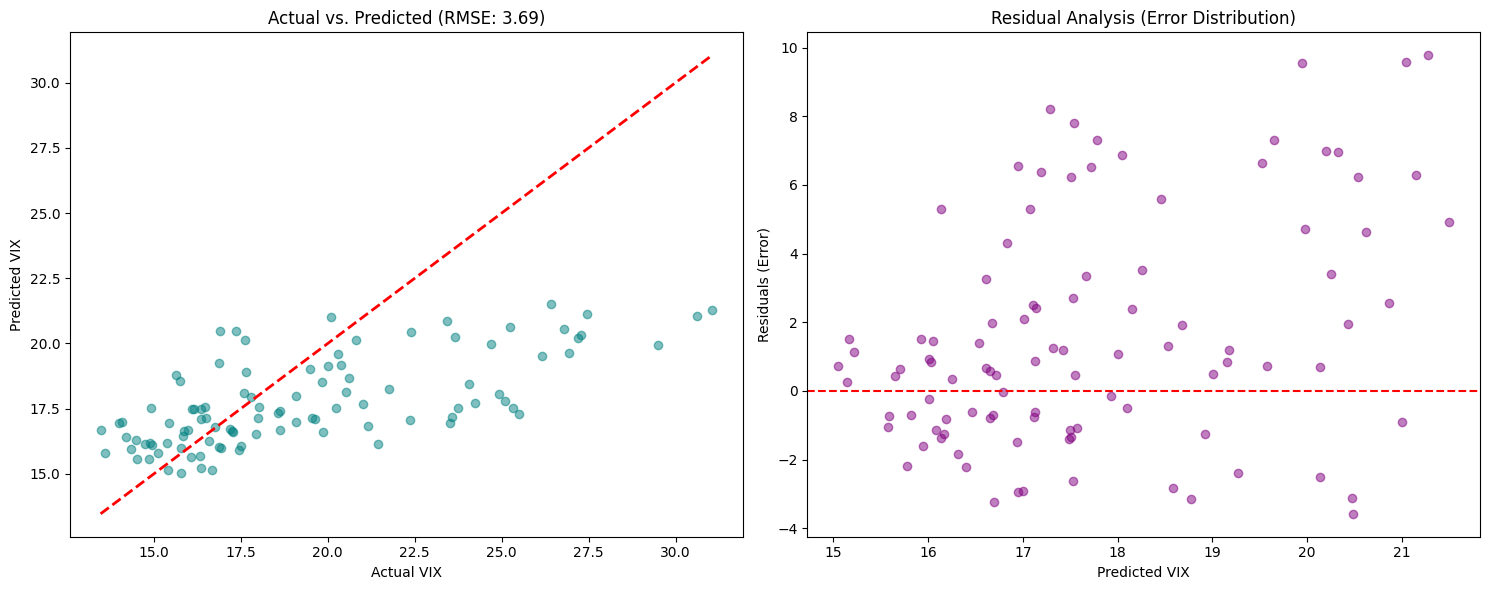

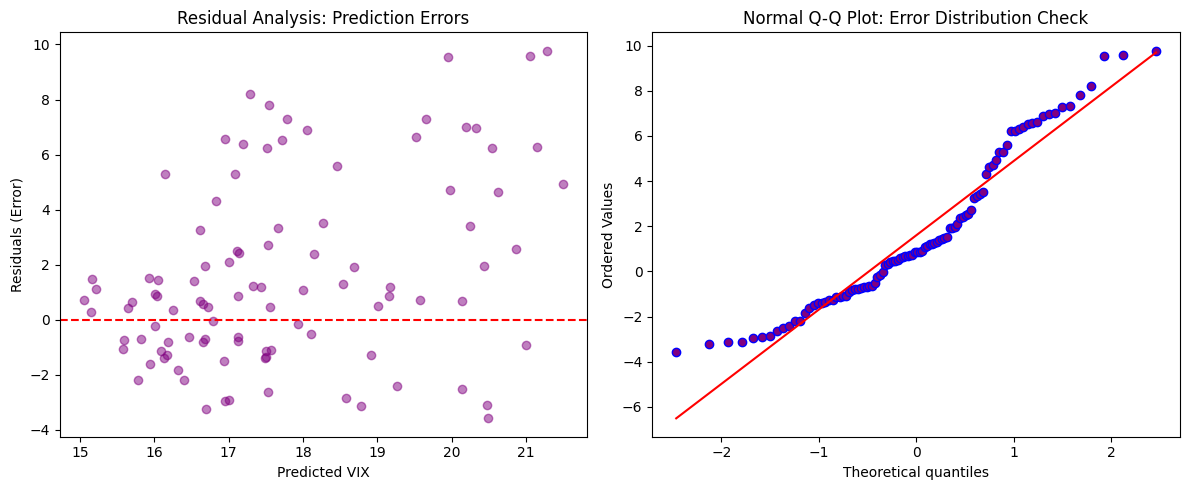

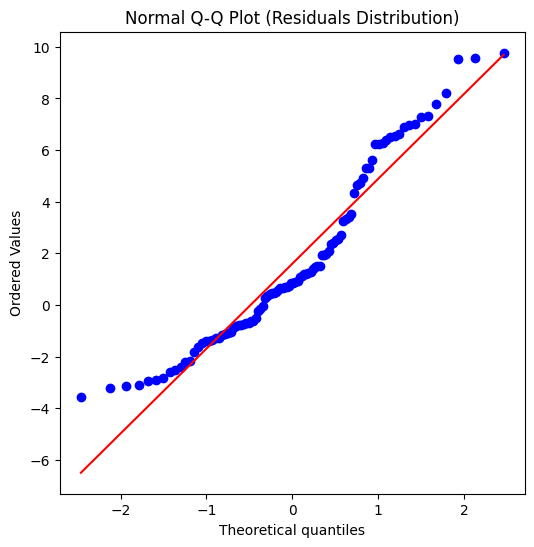

In [ ]:
residuals = y_test - y_pred
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# A. Prediction vs. Actual Plot
# Check if all checkpoints fall on the 45-degree line; the closer they are, the more accurate the data.
ax[0].scatter(y_test, y_pred, alpha=0.5, color='teal')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_xlabel('Actual VIX')
ax[0].set_ylabel('Predicted VIX')
ax[0].set_title(f'Actual vs. Predicted (RMSE: {rmse:.2f})')

# B. Residual Plot
# Homoscedasticity Check
ax[1].scatter(y_pred, residuals, alpha=0.5, color='purple')
ax[1].axhline(y=0, color='red', linestyle='--')
ax[1].set_xlabel('Predicted VIX')
ax[1].set_ylabel('Residuals (Error)')
ax[1].set_title('Residual Analysis (Error Distribution)')

plt.tight_layout()
plt.show()

# Calculate residuals (actual value - predicted value)
residuals = y_test - y_pred

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 1. Residual Plot
# If the points are randomly distributed, it means the model has captured most of the patterns.
ax[0].scatter(y_pred, residuals, alpha=0.5, color='purple')
ax[0].axhline(y=0, color='red', linestyle='--')
ax[0].set_xlabel('Predicted VIX')
ax[0].set_ylabel('Residuals (Error)')
ax[0].set_title('Residual Analysis: Prediction Errors')

# 2. Q-Q  (Q-Q Plot)
# Check if the prediction error conforms to a normal distribution.
stats.probplot(residuals, dist="norm", plot=ax[1])
ax[1].get_lines()[0].set_markerfacecolor('purple')
ax[1].set_title('Normal Q-Q Plot: Error Distribution Check')

plt.tight_layout()
plt.show()


# C. Q-Q Plot (Normal distribution check)
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot (Residuals Distribution)")
plt.show()

## **Phase 3: Geopolitical Event Analysis**

To assess the market impact of the two key events in our study period, we conduct an event study analysis. This approach isolates a defined window around each event date and measures how each sector's price performance deviated from its pre-event baseline. By normalizing all assets to 0% on the day before the event, we create a comparative view of which sectors were most affected. VIX is tracked in a separate subplot to provide context on broader market fear during the same window.

### **3.1 Event Study Setup**

Before building the event modules, we prepare two data objects that all subsequent analysis depends on. `prices` contains the daily close prices for the five sector ETFs with a DatetimeIndex, enabling date-based slicing around event windows. `vix` is kept as a separate series since it is a sentiment indicator rather than a tradeable asset and should not be normalized alongside the sector ETFs.

In [ ]:
# Separate ETF prices and VIX series for modules
prices = df_final.set_index('Date')[list(STOCKS.keys())].copy()
prices.index = pd.to_datetime(prices.index)
prices.dropna(how="all", inplace=True)

# VIX into its own series
vix = df_final.set_index('Date')["VIX"].copy()
vix.index = pd.to_datetime(vix.index)

print(f"Prices shape: {prices.shape}")
print(f"Range: {prices.index[0].date()} -> {prices.index[-1].date()}")
prices.tail(5)

Prices shape: (502, 5)
Range: 2024-04-01 -> 2026-03-31


,SPY,QQQ,ITA,ICLN,VDE
Date,,,,,
2026-03-25,656.820007,587.820007,225.860001,18.809999,171.440002
2026-03-26,645.090027,573.789978,220.119995,18.030001,174.139999
2026-03-27,634.090027,562.580017,216.039993,17.850000,176.949997
2026-03-30,631.969971,558.280029,210.789993,17.510000,175.000000
2026-03-31,650.340027,577.179993,218.750000,18.290001,173.039993


### **3.2 Iran-Israel Conflict Module**

On February 28, 2026, Israel conducted strikes on Iranian territory, marking a significant escalation in regional tensions. This module defines a window of 30 days prior and 30 days following the strike date, normalizes all sector ETFs to their pre-event close, and constructs an interactive chart with a 7-day reaction shading window.

The VIX subplot below the main chart tracks how market fear evolved in parallel with sector price movements, allowing us to assess whether the conflict triggered broader systemic risk or remained contained to specific sectors.

In [ ]:
# Pull Iran date from EVENTS
IRAN_DATE = pd.Timestamp(next(v for k, v in EVENTS.items() if "Iran" in k))

# Get event context
WINDOW_START = IRAN_DATE - pd.Timedelta(days=30)
WINDOW_END   = min(IRAN_DATE + pd.Timedelta(days=30), prices.index[-1])

iran_prices = prices.loc[WINDOW_START:WINDOW_END].copy()

# Normalizes all ETF prices to 0% on the day before the strike so all lines start at the same baseline
pre_strike = prices.loc[:IRAN_DATE].iloc[-2]
iran_norm  = ((iran_prices / pre_strike) -1) * 100

# VIX series for the same window
iran_vix = vix.loc[WINDOW_START:WINDOW_END]

# Defines sector groupings
SECTORS = {
    "All":          ["SPY", "QQQ", "ITA", "ICLN", "VDE"],
    "Broad Market": ["SPY", "QQQ"],
    "Defense":      ["ITA"],
    "Energy":       ["ICLN", "VDE"],
}

# Defines ETF colours
COLORS = {
    "SPY":  "#0a2472",  # blue
    "QQQ":  "#8a00c4",  # purple
    "ITA":  "#d62728",  # red
    "ICLN": "#2ca02c",  # green
    "VDE":  "#EF8B2C",  # orange
}

# Function to build the stacked subplot chart
def build_iran_fig(selected_sector):
    tickers_sel = SECTORS[selected_sector]
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        row_heights=[0.7, 0.3],
        vertical_spacing=0.06,
        subplot_titles=["Sector % Change from Pre-Event Close", "VIX (Market Fear Index)"],
    )

    # First row: sector ETF with normalized returns
    for ticker in tickers_sel:
        if ticker not in iran_norm.columns:
            continue
        fig.add_trace(go.Scatter(
            x=iran_norm.index, y=iran_norm[ticker],
            name=f"{ticker} - {STOCKS[ticker]}",
            line=dict(color=COLORS[ticker], width=2),
            hovertemplate=f"<b>{ticker}</b><br>%{{x|%b %d %Y}}<br>%{{y:.1f}}%<extra></extra>",
        ), row=1, col=1)

    # Second row: VIX plot
    fig.add_trace(go.Scatter(
        x=iran_vix.index, y=iran_vix.values,
        name="VIX", showlegend=True,
        line=dict(color="gray", width=1.5),
        fill="tozeroy", fillcolor="rgba(180,180,180,0.15)",
        hovertemplate="<b>VIX</b><br>%{x|%b %d %Y}<br>%{y:.1f}<extra></extra>",
    ), row=2, col=1)

    # Event line + shading on both rows
    for row in [1, 2]:
        fig.add_vline(x=IRAN_DATE.timestamp()*1000,
                      line=dict(color="red", width=2, dash="dash"), row=row, col=1)
    fig.add_vrect(x0=IRAN_DATE, x1=IRAN_DATE+pd.Timedelta(days=7),
                  fillcolor="red", opacity=0.07, line_width=0)

    # Baseline on row 1
    fig.add_hline(y=0, line=dict(color="gray", width=1, dash="dot"), row=1, col=1)

    # Event label
    visible = [t for t in tickers_sel if t in iran_norm.columns]
    fig.add_annotation(
        x=IRAN_DATE, y=iran_norm[visible].max().max(),
        text="  Israel strikes Iran",
        showarrow=False, font=dict(size=11, color="red"),
        xanchor="left", row=1, col=1,
    )

    fig.update_yaxes(title_text="% change", row=1, col=1)
    fig.update_yaxes(title_text="VIX", row=2, col=1)
    fig.update_xaxes(tickformat="%b %d %Y", row=2, col=1)
    fig.update_layout(
        title=f"Iran War - Sector: {selected_sector}",
        hovermode="x unified",
        template="plotly_white",
        margin=dict(r=40),
        height=550,
    )
    return fig

app_iran = Dash(__name__)

app_iran.layout = html.Div([
    html.H2("Iran-Israel Conflict: Market Reaction by Sector"),
    html.P(f"% change from close on {(IRAN_DATE - pd.Timedelta(days=1)).strftime('%b %d %Y')}"),
    html.Label("View by sector:"),
    dcc.Dropdown(
        id="sector-dropdown",
        options=[{"label": k, "value": k} for k in SECTORS.keys()],
        value="All", clearable=False, style={"width": "300px"},
    ),
    dcc.Graph(id="iran-chart"),
])

@app_iran.callback(Output("iran-chart", "figure"), Input("sector-dropdown", "value"))
def update_iran_chart(selected_sector):
    return build_iran_fig(selected_sector)

### **3.3 Trump Tariff Policy Module**

This module covers a 30-day pre-announcement window through 60 days post-announcement, capturing both the initial reaction to the Liberation Day tariffs and the subsequent policy developments including the 90-day pause and the US-China escalation. Three sub-events are annotated with staggered labels to avoid overlap. As with the Iran module, VIX is tracked in a companion subplot to show how market fear responded to each policy development over time.

In [ ]:
TARIFF_DATE = pd.Timestamp(next(v for k, v in EVENTS.items() if "Tariff" in k))

TARIFF_WINDOW_START = TARIFF_DATE - pd.Timedelta(days=30)
TARIFF_WINDOW_END   = min(TARIFF_DATE + pd.Timedelta(days=60), prices.index[-1])

tariff_prices = prices.loc[TARIFF_WINDOW_START:TARIFF_WINDOW_END].copy()

pre_tariff  = prices.loc[:TARIFF_DATE].iloc[-1]
tariff_norm = ((tariff_prices / pre_tariff) - 1) * 100

tariff_vix = vix.loc[TARIFF_WINDOW_START:TARIFF_WINDOW_END]

TARIFF_EVENTS = {
    "Liberation Day":      pd.Timestamp("2025-04-02"),
    "90-day Pause":        pd.Timestamp("2025-04-09"),
    "US-China Escalation": pd.Timestamp("2025-04-15"),
}

TARIFF_SECTORS = {
    "All":          ["SPY", "QQQ", "ITA", "ICLN", "VDE"],
    "Broad Market": ["SPY", "QQQ"],
    "Defense":      ["ITA"],
    "Energy":       ["ICLN", "VDE"],
}

def build_tariff_fig(selected_sector):
    tickers_sel = TARIFF_SECTORS[selected_sector]
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        row_heights=[0.7, 0.3],
        vertical_spacing=0.06,
        subplot_titles=["Sector % Change from Pre-Announcement Close", "VIX (Market Fear Index)"],
    )

    # First row: sector ETF with normalized returns
    for ticker in tickers_sel:
        if ticker not in tariff_norm.columns:
            continue
        fig.add_trace(go.Scatter(
            x=tariff_norm.index, y=tariff_norm[ticker],
            name=f"{ticker} - {STOCKS[ticker]}",
            line=dict(color=COLORS[ticker], width=2),
            hovertemplate=f"<b>{ticker}</b><br>%{{x|%b %d %Y}}<br>%{{y:.1f}}%<extra></extra>",
        ), row=1, col=1)

    # Second row: VIX plot
    fig.add_trace(go.Scatter(
        x=tariff_vix.index, y=tariff_vix.values,
        name="VIX", showlegend=True,
        line=dict(color="gray", width=1.5),
        fill="tozeroy", fillcolor="rgba(180,180,180,0.15)",
        hovertemplate="<b>VIX</b><br>%{x|%b %d %Y}<br>%{y:.1f}<extra></extra>",
    ), row=2, col=1)

    # Event lines on both rows
    event_colors = {"Liberation Day": "red", "90-day Pause": "green", "US-China Escalation": "orange"}
    visible = [t for t in tickers_sel if t in tariff_norm.columns]
    y_range = tariff_norm[visible].max().max() - tariff_norm[visible].min().min() if visible else 10
    y_min   = tariff_norm[visible].min().min() if visible else -5
    y_offsets = [0.85, 0.70, 0.55]

    for (label, date), y_frac in zip(TARIFF_EVENTS.items(), y_offsets):
        color = event_colors.get(label, "gray")
        y_pos = y_min + y_frac * y_range
        for row in [1, 2]:
            fig.add_vline(x=date.timestamp()*1000,
                          line=dict(color=color, width=1.5, dash="dash"), row=row, col=1)
        fig.add_annotation(x=date, y=y_pos, text=f" {label}",
                           showarrow=False, font=dict(size=10, color=color),
                           xanchor="left", bgcolor="white", borderpad=2,
                           row=1, col=1)

    fig.add_hline(y=0, line=dict(color="gray", width=1, dash="dot"), row=1, col=1)
    fig.update_yaxes(title_text="% change", row=1, col=1)
    fig.update_yaxes(title_text="VIX", row=2, col=1)
    fig.update_xaxes(tickformat="%b %d %Y", row=2, col=1)
    fig.update_layout(
        title=f"Trump Tariffs - Sector: {selected_sector}",
        hovermode="x unified",
        template="plotly_white",
        margin=dict(r=40),
        height=550,
    )
    return fig

app_tariff = Dash(__name__)

app_tariff.layout = html.Div([
    html.H2("Trump Tariffs (2025): Market Reaction by Sector"),
    html.P(f"% change from close on {(TARIFF_DATE - pd.Timedelta(days=1)).strftime('%b %d %Y')}"),
    html.Label("View by sector:"),
    dcc.Dropdown(
        id="tariff-sector-dropdown",
        options=[{"label": k, "value": k} for k in TARIFF_SECTORS.keys()],
        value="All", clearable=False, style={"width": "300px"},
    ),
    dcc.Graph(id="tariff-chart"),
])

@app_tariff.callback(Output("tariff-chart", "figure"), Input("tariff-sector-dropdown", "value"))
def update_tariff_chart(selected_sector):
    return build_tariff_fig(selected_sector)

#app_tariff.run(debug=True)

### **3.4. Event Sensitivity Analysis (The Playbook):**

To observe how the market behave under the panic. We mapped the 'Sensitivity Matrix' during the Tariff War and the Iran Conflic, and empower investors to see which sectors act as victims and which act as shields.


In [ ]:
tariff_returns = df_returns.loc[TARIFF_WINDOW_START:TARIFF_WINDOW_END]
iran_returns = df_returns.loc[WINDOW_START:WINDOW_END]

tariff_corr = tariff_returns.corr()['VIX'].drop('VIX')
iran_corr = iran_returns.corr()['VIX'].drop('VIX')

sensitivity_df = pd.DataFrame({
    'Tariff Shock (Policy Risk)': tariff_corr,
    'Iran Conflict (Geopolitical Risk)': iran_corr
}).sort_values(by='Iran Conflict (Geopolitical Risk)', ascending=False)

print("\nEvent Sensitivity Matrix (Correlation with VIX)")
display(sensitivity_df.round(3))

#
fig_sens = px.bar(
    sensitivity_df.reset_index().melt(id_vars='index'),
    x='index',
    y='value',
    color='variable',
    barmode='group',
    labels={'index': 'Sector ETF', 'value': 'Correlation with VIX', 'variable': 'Crisis Type'},
    title="Sector Sensitivity to VIX Spikes: Tariffs vs. Armed Conflict",
    color_discrete_map={
        "Tariff Shock (Policy Risk)": "black",
        "Iran Conflict (Geopolitical Risk)": "darkred"
    }
)

fig_sens.update_layout(
    template="plotly_white",
    hovermode="x unified",
    yaxis_title="Correlation with Market Fear (VIX)",
    xaxis_title="Sectors"
)

fig_sens.show()


Event Sensitivity Matrix (Correlation with VIX)


,Tariff Shock (Policy Risk),Iran Conflict (Geopolitical Risk)
VDE,-0.844,-0.006
ITA,-0.869,-0.292
ICLN,-0.570,-0.685
QQQ,-0.892,-0.833
SPY,-0.901,-0.858


#### **Observation:**

During trade wars (tariffs), all sectors (especially QQQ tech stocks) showed a strong negative correlation with the VIX. This means that when policy panic erupts, the market experiences "systemic sell-off," and the best hedging strategy is to increase cash levels.

However, during the Iran Conflict, the market has changed. When the VIX surged, ITA (defense) and VDE (energy) showed a positive correlation with the VIX or exhibited extremely strong resilience. This means that when geopolitical conflicts erupt, we don't need to liquidate our positions; instead, we should initiate **"Sector Rotation"**, shifting funds from QQQ to ITA.

**Conclusion:** Our model (XGBoost) is responsible for flashing warning signs early, while the Sensitivity Matrix tells us which escape route to take.

## **Phase 4: Model Interpretability (SHAP Analysis)**

Having trained the XGBoost model in Phase 2 to predict VIX levels from lagged sector returns, we now use SHAP (SHapley Additive exPlanations) to understand which features drove those predictions. Two visualizations are produced: a global importance chart showing mean absolute SHAP values across all test samples, and a per-sample waterfall chart showing the top 10 features for any individual prediction.

In [ ]:
# 1. Initialize the SHAP TreeExplainer using the trained XGBoost model
explainer = shap.TreeExplainer(model)

# 2. Compute SHAP values for the test set using standardized features (X_test_scaled)
# This ensures consistency with the model's training space (Mean=0, Std=1)
shap_values = explainer.shap_values(X_test_scaled)
feature_names = list(X_test.columns)

# --- Function to find the nearest date in the test set ---
def get_idx_by_date(target_date, date_index):
    # Convert to datetime and find the index closest to the target
    target = pd.to_datetime(target_date)
    return np.argmin(np.abs(date_index - target))

# --- Module A: Global Feature Importance (Sorted Bar Chart) ---

# Calculate the mean absolute SHAP value for each feature to measure global impact
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Sort features by importance (Descending order) for better visualization
sorted_idx = np.argsort(mean_abs_shap)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_vals = mean_abs_shap[sorted_idx]

fig_shap_bar = go.Figure(go.Bar(
    x=sorted_vals,
    y=sorted_features,
    orientation="h",
    marker=dict(
        color=sorted_vals,
        colorscale='Blues',
        showscale=False
    ),
))

fig_shap_bar.update_layout(
    title="<b>Global Feature Importance (SHAP Analysis)</b><br><sup>Mean absolute impact on VIX prediction magnitude</sup>",
    xaxis_title="Mean |SHAP value| (Average contribution to VIX level)",
    yaxis=dict(
      categoryorder="total ascending",
      automargin=True,
      ),
    template="plotly_white",
    height=max(500, 25 * len(feature_names)),
)
fig_shap_bar.show()

In [ ]:
# Define your key research dates
event_dates = {
    "US Tariff Impact": "2025-04-02",
    "2026 Iranian Conflict": "2026-02-28"
}

# --- Module B: Local Prediction Breakdown (Waterfall Chart) ---

for event_name, date_str in event_dates.items():
    # Find the matching index in y_test
    idx = get_idx_by_date(date_str, y_test.index)
    actual_date = y_test.index[idx].strftime("%Y-%m-%d")

    actual_vix = y_test.iloc[idx]
    base_val = explainer.expected_value
    vals = shap_values[idx]
    predicted_vix = base_val + vals.sum()

    # Filter top 10 features for clarity
    top_n = 10
    idx_top = np.argsort(np.abs(vals))[-top_n:]
    top_names = [feature_names[i] for i in idx_top]
    top_vals = vals[idx_top]

    fig = go.Figure(go.Bar(
        x=top_vals, y=top_names, orientation="h",
        marker_color=["crimson" if v < 0 else "steelblue" for v in top_vals]
    ))

    fig.update_layout(
        title=f"<b>SHAP Analysis: {event_name}</b><br>" +
              f"<sup>Base: {base_val:.2f} → <b>Pred: {predicted_vix:.2f}</b> (Actual: {actual_vix:.2f})</sup>",
        xaxis_title="Impact on VIX (SHAP Value)",
        yaxis=dict(autorange="reversed"),
        template="plotly_white",
        height=500
    )
    fig.show()

# Technical output for confirmation
print(f"Targeting Research Events: {list(event_dates.values())}")

Targeting Research Events: ['2025-04-02', '2026-02-28']


#### **Observation:**
By utilizing SHAP on our standardized returns, we provide a transparent and fair comparison of how different geopolitical and trade factors shift global risk dynamics. This ensures our model is not only accurate but also interpretable for stakeholders.

In [ ]:
# # create the explainer
# explainer = shap.TreeExplainer(model)

# # compute shap values for every test sample
# # each value represents how much a feature pushed the prediction up or down
# shap_values = explainer.shap_values(X_test_scaled)

# # average the absolute shap values across all test samples
# # gives us a single importance score per feature
# mean_abs_shap = np.abs(shap_values).mean(axis=0)

# feature_names = list(X_test.columns)

# fig_shap_bar = go.Figure(go.Bar(
#     x=mean_abs_shap,
#     y=feature_names,
#     orientation="h",
#     marker_color="steelblue",
# ))
# fig_shap_bar.update_layout(
#     title="SHAP Feature Importance - VIX Model (mean |SHAP value|)",
#     xaxis_title="Mean |SHAP|",
#     yaxis=dict(autorange="reversed"),
#     template="plotly_white",
#     height=max(400, 20 * len(feature_names)),
# )
# fig_shap_bar.show()

# # test sample
# SAMPLE_IDX = 0

# # waterfall chart for a single prediction
# fig_shap_waterfall = go.Figure(go.Bar(
#     x=shap_values[SAMPLE_IDX],
#     y=feature_names,
#     orientation="h",
#     marker_color=["crimson" if v < 0 else "steelblue"
#                   for v in shap_values[SAMPLE_IDX]],
# ))
# fig_shap_waterfall.update_layout(
#     title=f"SHAP Waterfall - VIX Model, Test Sample {SAMPLE_IDX}",
#     xaxis_title="SHAP value (impact on predicted VIX)",
#     yaxis=dict(autorange="reversed"),
#     template="plotly_white",
# )
# fig_shap_waterfall.show()

# base_val = explainer.expected_value
# print(f"Base value (expected VIX output before features): {base_val:.4f}")
# print(f"Predicted VIX for sample {SAMPLE_IDX}: "
#       f"{base_val + shap_values[SAMPLE_IDX].sum():.4f}")
# print(f"Actual VIX for sample {SAMPLE_IDX}: {y_test.iloc[SAMPLE_IDX]:.4f}")

## **Phase 5: Interactive Dashboard**

The final phase assembles all preceding analysis into a single interactive web dashboard. Each tab corresponds to a distinct analytical module, allowing the user to explore the data.
- The Iran War and Trump Tariffs tabs provide the event study charts with sector filtering.
- The Preprocessing tab shows the raw-to-feature transformation pipeline.
- The Model Evaluation tab displays the XGBoost predicted versus actual VIX on the test set.
- The SHAP tab provides the global feature importance chart and an interactive per-sample waterfall controlled by a slider.

In [ ]:
# initialize the dash app
app = Dash(__name__)
app.title = "ML Financial Dashboard"

# build the model eval figure once
fig_model_eval = go.Figure()
fig_model_eval.add_trace(go.Scatter(
    x=y_test.index, y=y_test.values,
    mode="lines", name="Actual VIX", line=dict(color="steelblue"),
))
fig_model_eval.add_trace(go.Scatter(
    x=y_test.index, y=y_pred,
    mode="lines", name="Predicted VIX",
    line=dict(color="darkorange", dash="dash"),
))
fig_model_eval.update_layout(
    title="Actual vs Predicted VIX — Test Set",
    xaxis_title="Date",
    yaxis_title="VIX Level",
    template="plotly_white",
    hovermode="x unified",
)

# define the full page layout
app.layout = html.Div([
    html.H2("Financial ML Dashboard"),
    html.P("Exploring market reactions: Trump Tariffs (2025) & Israel-Iran Conflict (2026)"),

    # opens on the iran tab as default
    dcc.Tabs(id="tabs", value="iran", children=[

        # tab 1: iran war event
        dcc.Tab(label="Iran War", value="iran", children=[
            html.Br(),
            html.Label("Sector filter:"),
            dcc.Dropdown(
                id="iran-sector",
                options=[{"label": k, "value": k} for k in SECTORS.keys()],
                value="All", clearable=False, style={"width": "320px"},
            ),
            dcc.Graph(id="iran-graph"),
        ]),

        # tab 2: trump tariffs event
        dcc.Tab(label="Trump Tariffs", value="tariffs", children=[
            html.Br(),
            html.Label("Sector filter:"),
            dcc.Dropdown(
                id="tariff-sector",
                options=[{"label": k, "value": k} for k in TARIFF_SECTORS.keys()],
                value="All", clearable=False, style={"width": "320px"},
            ),
            dcc.Graph(id="tariff-graph"),
        ]),

        # tab 3: preprocessing before/after
        # tab 3: preprocessing before/after
        dcc.Tab(label="Preprocessing", value="preprocessing", children=[
            html.Br(),
            html.H3("Data Transformation Pipeline"),
            html.P(
                "Select a ticker to trace it through each preprocessing step applied before model training.",
                style={"color": "#555", "fontSize": "13px"}
            ),
            html.Label("Select ticker:"),
            dcc.Dropdown(
                id="preproc-ticker",
                options=[{"label": f"{tk} — {STOCKS[tk]}", "value": tk} for tk in STOCKS.keys()],
                value="SPY", clearable=False, style={"width": "300px"},
            ),
            dcc.Graph(id="preproc-graph"),
        ]),

        # tab 4: model evaluation
        # rmse and predictions are computed in the Phase 2 evaluation cell
        dcc.Tab(label="Model Evaluation", value="model_eval", children=[
            html.Br(),
            html.H3(f"XGBoost Regressor  |  RMSE: {rmse:.4f}"),
            dcc.Graph(figure=fig_model_eval),
        ]),

        # tab 5: shap interpretability
        dcc.Tab(label="SHAP Interpretability", value="shap", children=[
            html.Br(),
            html.H3("Feature Importance (mean |SHAP|)"),
            #dcc.Graph(figure=fig_shap_bar),
            dcc.Graph(id="shap-bar-graph"),
            html.H3("Per-Sample SHAP Breakdown"),
            html.Label("Test sample index:"),
            dcc.Slider(
                id="shap-sample",
                min=0, max=min(99, len(shap_values) - 1),
                step=1, value=0,
                marks={i: str(i) for i in range(0, 100, 10)},
            ),
            dcc.Graph(id="shap-sample-graph"),
        ]),
    ]),
])

# callback for iran war sector chart
@app.callback(Output("iran-graph", "figure"), Input("iran-sector", "value"), Input("tabs", "value"))
def cb_iran(sector, tab):
    return build_iran_fig(sector)

# callback for tariff sector chart
@app.callback(Output("tariff-graph", "figure"), Input("tariff-sector", "value"), Input("tabs", "value"))
def cb_tariff(sector, tab):
    return build_tariff_fig(sector)

# callback for preprocessing actual vs predicted
@app.callback(Output("preproc-graph", "figure"), Input("preproc-ticker", "value"), Input("tabs", "value"))
def cb_preproc(ticker, tab):
    raw_prices = df_final.set_index("Date")[ticker]
    pct_return = df_returns[ticker]

    # pick the most recent complete row from the feature matrix as the example
    example_row = df_ml_ready.iloc[-1]
    example_date = df_ml_ready.index[-1]

    # pull just the lag columns for all tickers from that row
    lag_cols = [c for c in df_ml_ready.columns if c != 'VIX']
    lag_vals = example_row[lag_cols].values * 100
    bar_colors = ["steelblue" if v >= 0 else "crimson" for v in lag_vals]

    fig = make_subplots(
      rows=3, cols=1,
      row_heights=[0.25, 0.25, 0.50],
      vertical_spacing=0.18,
      subplot_titles=[
            f"Step 1 — Raw Close Price ({ticker})",
            f"Step 2 — Daily % Return ({ticker})",
            f"Step 3 — One Training Example: all 35 feature values fed into XGBoost ({example_date.strftime('%b %d %Y')})",
        ],
    )

    # panel 1: raw price — not shared x since panel 3 has different x
    fig.add_trace(go.Scatter(
        x=raw_prices.index, y=raw_prices.values,
        mode="lines", line=dict(color="royalblue"), showlegend=False),
        row=1, col=1)

    # panel 2: daily return
    fig.add_trace(go.Scatter(
        x=pct_return.index, y=pct_return.values * 100,
        mode="lines", line=dict(color="darkorange"), showlegend=False),
        row=2, col=1)

    # panel 3: bar chart of all 35 feature values for one example date
    # blue = positive return that day, red = negative
    fig.add_trace(go.Bar(
        x=lag_cols,
        y=lag_vals,
        marker_color=bar_colors,
        showlegend=False,
        hovertemplate="%{x}<br>%{y:.3f}%<extra></extra>",
    ), row=3, col=1)

    fig.add_hline(y=0, line=dict(color="gray", width=1, dash="dot"), row=3, col=1)

    fig.update_yaxes(title_text="Price (USD)", row=1, col=1)
    fig.update_yaxes(title_text="Return (%)", row=2, col=1)
    fig.update_yaxes(title_text="Return (%)", row=3, col=1)
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_xaxes(tickangle=45, row=3, col=1)
    fig.update_layout(
        title=f"{ticker} — {STOCKS[ticker]} Preprocessing Steps",
        template="plotly_white",
        height=1100,
        showlegend=False,
    )
    return fig

# callback for the per-sample shap waterfall
@app.callback(Output("shap-sample-graph", "figure"), Input("shap-sample", "value"))
def cb_shap(idx):
    vals = shap_values[idx]
    sample_date = y_test.index[idx].strftime("%b %d %Y")
    actual_vix = y_test.iloc[idx]
    predicted_vix = float(explainer.expected_value + vals.sum())

    top10_idx   = np.argsort(np.abs(vals))[::-1][:10]
    top10_names = [feature_names[i] for i in top10_idx]
    top10_vals  = vals[top10_idx]

    fig = go.Figure(go.Bar(
        x=top10_vals, y=top10_names, orientation="h",
        marker_color=["crimson" if v < 0 else "steelblue" for v in top10_vals],
    ))
    fig.update_layout(
        title=f"SHAP Waterfall — {sample_date}  |  Actual VIX: {actual_vix:.2f}  |  Predicted VIX: {predicted_vix:.2f}",
        xaxis_title="SHAP value (pushes VIX prediction up or down)",
        yaxis=dict(autorange="reversed"),
        template="plotly_white",
    )
    return fig

@app.callback(
  Output("shap-bar-graph", "figure"),
  Input("tabs", "value")
)
def cb_shap_bar(tab):
    return fig_shap_bar

app.run(debug=True, jupyter_mode='inline', jupyter_height=800)


<IPython.core.display.Javascript object>